<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Day_31_Recurrent_Neural_Networks_(RNNs).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully!
Our Dataset:


,Sequence,Efficiency
0,GTCACCTCTGACCAGGCTGCGGG,0.72
1,GAAAGCAGTCAAGCGAGCGCAGG,0.15
2,CCTCTATACCCTGGGACCACAGG,0.88
3,GTAGCGACCGAGCGCCCGACTGG,0.45
4,TTCGACCTCATCCCAGGCACAGG,0.68


Shape of training data: (9, 23, 4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,489 (5.82 KB)

 Trainable params: 1,489 (5.82 KB)

 Non-trainable params: 0 (0.00 B)

Training complete!


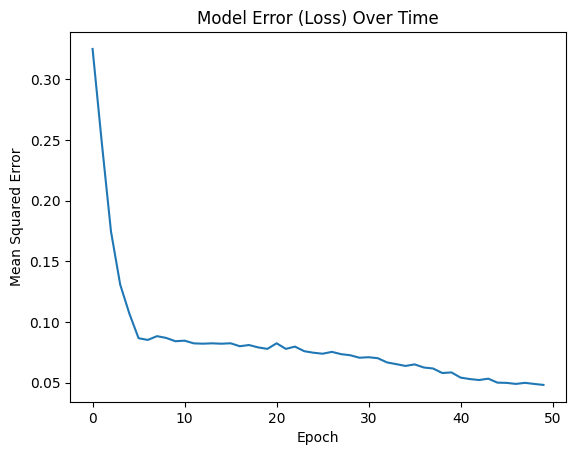

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step

--- Results on Test Data ---
Sample 1: Actual Score = 0.40 | Predicted Score = 0.41
Sample 2: Actual Score = 0.85 | Predicted Score = 0.79
Sample 3: Actual Score = 0.72 | Predicted Score = 0.49


In [5]:
# -*- coding: utf-8 -*-

"""Colab-Recurrent Neural Networks (RNNs)-Dr Bhupender-16-07-2026.ipynb

Automatically generated by Colab.

CRISPR Guide RNA On-Target Prediction using LSTM

Text Block 1: Import libraries

"""

# Import necessary libraries

import numpy as np

import pandas as pd

import io

import matplotlib.pyplot as plt

# Deep Learning libraries (TensorFlow and Keras)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM, Dense

from sklearn.model_selection import train_test_split

print("Libraries imported successfully!")

"""Text Block 2: Loading Dataset"""

# A small sample of real CRISPR sequence data and their efficiency scores

csv_data = """Sequence,Efficiency

GTCACCTCTGACCAGGCTGCGGG,0.72

GAAAGCAGTCAAGCGAGCGCAGG,0.15

CCTCTATACCCTGGGACCACAGG,0.88

GTAGCGACCGAGCGCCCGACTGG,0.45

TTCGACCTCATCCCAGGCACAGG,0.68

ATTGACTGCCCTACTGCGGCAGG,0.92

GGCCTAGCGACCCAGTACCCGGG,0.31

AACCTGACCGTCGACCCAATAGG,0.22

GGACCACCGACTGACCGGACAGG,0.79

CTTGACCAGCCTAGCCCACCAGG,0.85

ATCGACCGATCCAGCCCGTTAGG,0.40

GCTAGCTAGCTAGCTAGCTAGGG,0.12

"""

# Read the data into a Pandas DataFrame

df = pd.read_csv(io.StringIO(csv_data))

print("Our Dataset:")

display(df.head()) # Show the first 5 rows

"""Text Block 3: One-Hot Encoding"""

# Function to convert a DNA sequence into a one-hot encoded matrix

def sequence_to_onehot(sequence):

  mapping = {

'A': [1, 0, 0, 0],

'C': [0, 1, 0, 0],

'G': [0, 0, 1, 0],

'T': [0, 0, 0, 1]

}

  # For every letter in the sequence, get its [1,0,0,0] array

  onehot = [mapping[letter] for letter in sequence]

  return np.array(onehot)

# Apply the function to all sequences in our dataframe

X = np.array([sequence_to_onehot(seq) for seq in df['Sequence']])

y = np.array(df['Efficiency']) # The scores we want to predict

# Split data: 80% for training the model, 20% for testing it later

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of training data: {X_train.shape}")

# Explanation of shape: (Number of samples, 23 nucleotides, 4 DNA letters)

"""Text Block 4: Building the LSTM

The Layers:

LSTM Layer: This is the brain reading the sequence. We set it to 16 "units" (neurons). The input_shape tells it to expect 23 steps (nucleotides) and 4 features per step (the one-hot encoding).

Dense Layer: A standard neural network layer to process the LSTM's findings.

Output Layer: A final Dense layer with exactly 1 neuron. Because we are predicting a single continuous number (the efficiency score), we use a linear activation function.

"""

# Initialize the model

model = Sequential()

# Add the LSTM layer

# parameters: 16 = number of hidden LSTM cells (memory power)

model.add(LSTM(16, input_shape=(23, 4)))

# Add a standard fully-connected (Dense) layer to interpret the LSTM output

model.add(Dense(8, activation='relu')) # relu helps the network learn non-linear patterns

# Output layer: 1 neuron to predict the final efficiency score

model.add(Dense(1, activation='linear'))

# Compile the model

# 'adam' is the optimizer (the algorithm that updates the weights to minimize errors)

# 'mse' (Mean Squared Error) is the loss function (how we measure how wrong the model is)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary() # Prints a map of our network

"""Text Block 5: Training the Model"""

# Train the model and save the training history

history = model.fit(

X_train,

y_train,

epochs=50, # Number of passes through the data

batch_size=2, # Number of samples per gradient update

verbose=0 # Set to 0 to hide the spam of 50 progress bars, set to 1 to see them

)

print("Training complete!")

# Plot the training loss to see how the model improved over time

plt.plot(history.history['loss'])

plt.title('Model Error (Loss) Over Time')

plt.ylabel('Mean Squared Error')

plt.xlabel('Epoch')

plt.show()

"""Text Block 6: Testing"""

# Make predictions on the unseen test data

predictions = model.predict(X_test)

# Print out the results side-by-side

print("\n--- Results on Test Data ---")

for i in range(len(X_test)):

  actual = y_test[i]

  predicted = predictions[i][0]

  print(f"Sample {i+1}: Actual Score = {actual:.2f} | Predicted Score = {predicted:.2f}")